In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Chargement des données
# Assure-toi que le fichier CC GENERAL.csv est dans le bon dossier
df = pd.read_csv('CC GENERAL.csv')

print(f"Dimensions du dataset : {df.shape}")
df.head()

Dimensions du dataset : (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
# La colonne CUST_ID n'a aucune valeur prédictive/comportementale, on la retire
df_clustering = df.drop('CUST_ID', axis=1)

# Traitement des valeurs manquantes (CREDIT_LIMIT et MINIMUM_PAYMENTS)
# Remplacement par la médiane pour éviter l'impact des valeurs extrêmes
df_clustering['MINIMUM_PAYMENTS'] = df_clustering['MINIMUM_PAYMENTS'].fillna(df_clustering['MINIMUM_PAYMENTS'].median())
df_clustering['CREDIT_LIMIT'] = df_clustering['CREDIT_LIMIT'].fillna(df_clustering['CREDIT_LIMIT'].median())

# Standardisation des données (Étape critique pour K-Means et la distance Euclidienne)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# df_scaled est maintenant un array numpy prêt pour le clustering

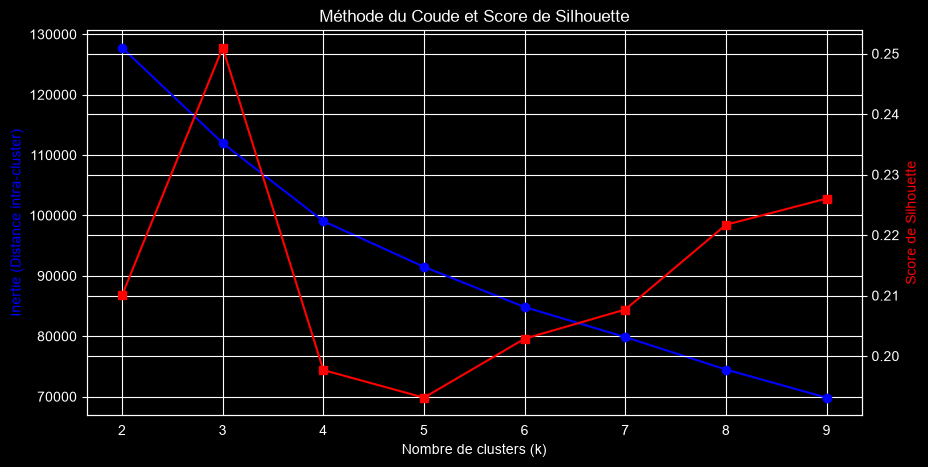

In [6]:
# Recherche du nombre optimal de clusters (k) avec l'Inertie (Elbow) et le Silhouette Score
inertias = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    # Calcul du score de silhouette
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Visualisation pour choisir k
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, inertias, marker='o', color='b')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie (Distance intra-cluster)', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker='s', color='r')
ax2.set_ylabel('Score de Silhouette', color='r')

plt.title('Méthode du Coude et Score de Silhouette')
plt.show()

# Supposons que k=4 offre un bon compromis (à confirmer avec le graphique)
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(df_scaled)

# Ajout des labels au dataframe d'origine pour l'interprétation
df['Cluster'] = cluster_labels

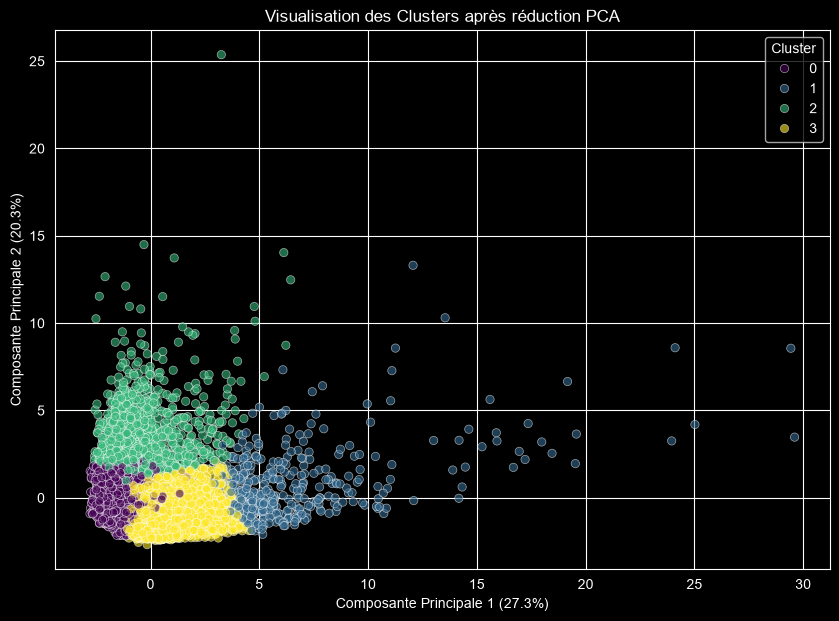

In [7]:
# Réduction de dimension avec PCA (2 composantes principales pour la 2D)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

# Création d'un dataframe pour la visualisation
df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels

# Visualisation des clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=df_pca, alpha=0.6)
plt.title('Visualisation des Clusters après réduction PCA')
plt.xlabel(f'Composante Principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Composante Principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Cluster')
plt.show()

In [8]:
# Analyse des profils de chaque cluster
cluster_profiling = df.drop('CUST_ID', axis=1).groupby('Cluster').mean()

# Affichage de quelques colonnes clés pour comprendre le comportement
cols_of_interest = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
print(cluster_profiling[cols_of_interest].round(2))

         BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS
Cluster                                                          
0        1012.66     270.04        596.51       3278.71    974.26
1        3551.15    7681.62        653.64       9696.94   7288.74
2        4602.45     501.86       4521.51       7546.16   3484.05
3         894.91    1236.18        210.57       4213.21   1332.19
